<a href="https://colab.research.google.com/github/appling2024/MSP/blob/Liza/word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

План по теории:
1. Что такое дистрибутивная семантика?
2. Что такое дистрибутивная гипотеза?
3. Word2vec.

In [24]:
!pip install numpy scipy gensim

In [25]:
import gensim
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [26]:
#обучаем модель Word2Vec
filename = 'skazkilem.txt'

model = Word2Vec(
    LineSentence(filename),  # читаем файл
    vector_size=150,         # размер вектора
    window=1,                # размер контекста
    min_count=5,             # игнорируем редкие слова (меньше 5)
    workers=2                # количество потоков для ускорения
)

model.init_sims(replace=True)
model.save('skazki.model')     # сохраняем модель

<ipython-input-26-3468714226>:12: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  model.init_sims(replace=True)


In [27]:
#загружаем модель
model = Word2Vec.load('skazki.model')

In [28]:
# Функция, чтобы показать похожие слова
def print_similar_words(word, topn=10):
    print(f"Похожие слова для '{word}':")
    similar = model.wv.most_similar(positive=[word], topn=topn)
    for w, score in similar:
        print(f"  {w} -> {score:.4f}")
    print()

In [29]:
#проверяем похожие слова
words_to_test = ['чудо', 'рыба', 'лес', 'обман', 'солнце']
for w in words_to_test:
    print_similar_words(w)

Похожие слова для 'чудо':
  скажи: -> 0.9963
  кажись, -> 0.9955
  сделаю». -> 0.9949
  нам, -> 0.9947
  спасибо -> 0.9947
  слышать -> 0.9946
  хочу». -> 0.9944
  хитрый -> 0.9943
  будет!» -> 0.9943
  она, -> 0.9942

Похожие слова для 'рыба':
  тело -> 0.9959
  выгнать -> 0.9953
  крылышко -> 0.9949
  разбойник -> 0.9949
  снести -> 0.9948
  зуб -> 0.9947
  нищий -> 0.9946
  высунуть -> 0.9945
  рассыпаться -> 0.9944
  опуститься -> 0.9943

Похожие слова для 'лес':
  дворец -> 0.9846
  сад -> 0.9840
  город -> 0.9836
  изба -> 0.9798
  лес, -> 0.9704
  палата -> 0.9692
  некий -> 0.9666
  море -> 0.9621
  избушка -> 0.9607
  войти -> 0.9603

Похожие слова для 'обман':
  голь -> 0.9930
  маленький -> 0.9928
  горох -> 0.9926
  рота -> 0.9925
  двести -> 0.9925
  кто-то -> 0.9924
  право -> 0.9919
  работать -> 0.9918
  дивиться -> 0.9918
  пёрышко -> 0.9918

Похожие слова для 'солнце':
  муха -> 0.9968
  кобель -> 0.9967
  яблоня -> 0.9964
  кузнец -> 0.9962
  суд -> 0.9962
  охотник 

In [30]:
#считаем сходство между двумя словами
similarity_score = model.wv.similarity('чудо', 'царство')
print(f"Сходство между 'чудо' и 'царство': {similarity_score:.4f}\n")

Сходство между 'чудо' и 'царство': 0.8639



In [31]:
#функция для визуализации слов с помощью t-SNE -- техники нелинейного снижения размерности и визуализации многомерных переменных.
#t-SNE -- t-distributed stochastic neighbor embedding
def tsnescatterplot(model, word, additional_words=[]):
    sns.set_style("darkgrid")

    arrays = np.empty((0, model.vector_size), dtype='f')  # массив векторов слов
    word_labels = [word]     # подписи слов на графике
    color_list = ['red']     # цвета для слов (красный — исходное слово)

    #добавляем вектор исходного слова
    arrays = np.append(arrays, model.wv[word].reshape(1, -1), axis=0)

    #добавляем вектора похожих слов
    close_words = model.wv.most_similar([word], topn=10)
    for wrd, _ in close_words:
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)
        word_labels.append(wrd)
        color_list.append('blue')  # похожие слова — синие

    #добавляем дополнительные слова (если есть)
    for wrd in additional_words:
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)
        word_labels.append(wrd)
        color_list.append('green')  # дополнительные — зелёные

    #сначала уменьшаем размерность с помощью PCA
    pca_result = PCA(n_components=4).fit_transform(arrays)

    #потом уменьшаем до 2D с помощью t-SNE для визуализации
    tsne = TSNE(n_components=2, perplexity=min(5, len(arrays)), n_iter=1000, random_state=0)
    tsne_result = tsne.fit_transform(pca_result)

    #создаём таблицу для удобного рисования
    df = pd.DataFrame({
        'x': tsne_result[:, 0],
        'y': tsne_result[:, 1],
        'word': word_labels,
        'color': color_list
    })

    #рисуем график
    plt.figure(figsize=(10, 10))
    sns.scatterplot(data=df, x='x', y='y', hue='color', palette=['red', 'blue', 'green'], legend=False, s=100)

    #подписываем слова рядом с точками
    for i in range(len(df)):
        plt.text(df.x[i]+0.1, df.y[i]+0.1, df.word[i], fontsize=12)

    plt.title(f't-SNE визуализация для слова {word}')
    plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
<ipython-input-31-226681444>:43: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(data=df, x='x', y='y', hue='color', palette=['red', 'blue', 'green'], legend=False, s=100)


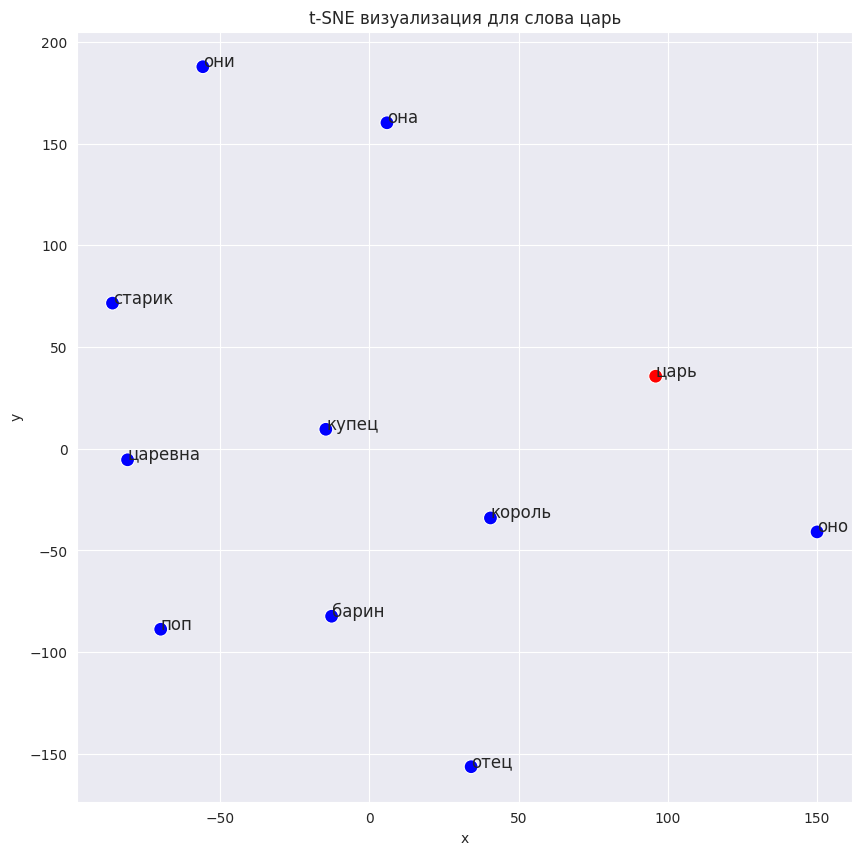

In [32]:
#визуализируем слово 'царь'
tsnescatterplot(model, 'царь')